In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("customer_churn_processed.csv")

X = df.drop("Churn", axis=1)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

churn_probability = model.predict_proba(X_scaled)[:, 1]
df["Churn_Probability"] = churn_probability

In [44]:
from sklearn.preprocessing import MinMaxScaler
value_scaler = MinMaxScaler()
df[["MonthlyCharges_Norm",
    "TotalCharges_Norm",
    "Tenure_Norm"]] = value_scaler.fit_transform(
    df[["MonthlyCharges", "TotalCharges", "tenure"]]
)

In [45]:
df["Customer_Value"] = (
    df["MonthlyCharges_Norm"] +
    df["TotalCharges_Norm"] +
    df["Tenure_Norm"]
) / 3

In [46]:
df["Retention_Priority"] = (
    df["Churn_Probability"] *
    df["Customer_Value"]
)

In [47]:
df = df.sort_values(
    by="Retention_Priority",
    ascending=False
)

In [48]:
top10 = df[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn_Probability",
    "Customer_Value",
    "Retention_Priority"
]].head(10)

top10

,tenure,MonthlyCharges,TotalCharges,Churn_Probability,Customer_Value,Retention_Priority
6444,0.593974,1.171785,1.141683,0.630856,0.673912,0.425142
4067,1.042158,1.126911,1.557083,0.558624,0.757294,0.423042
2070,0.960670,1.205026,1.460639,0.560466,0.747290,0.418830
4257,0.553230,1.318043,1.138506,0.611201,0.683534,0.417776
5289,1.123646,1.366242,1.816788,0.512561,0.813206,0.416817
3769,0.349510,1.116938,0.840219,0.678133,0.613987,0.416365
3993,0.268022,1.161813,0.773269,0.689420,0.603238,0.415884
3675,0.553230,1.203364,1.057416,0.624820,0.665021,0.415519
2943,0.349510,1.163475,0.871786,0.668174,0.621383,0.415192
3325,0.756950,1.096994,1.160323,0.602926,0.686854,0.414122


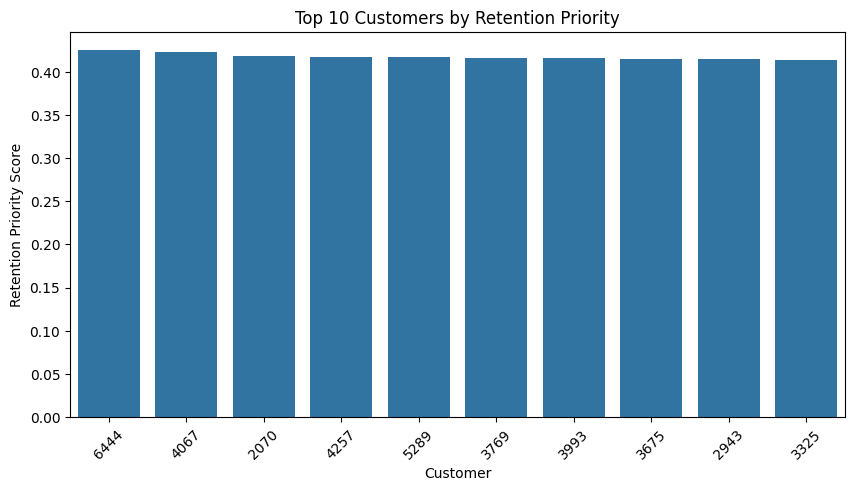

In [49]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top10,
    x=top10.index.astype(str),
    y="Retention_Priority"
)

plt.title("Top 10 Customers by Retention Priority")
plt.xlabel("Customer")
plt.ylabel("Retention Priority Score")
plt.xticks(rotation=45)

plt.show()

# Observations
1.Customer Value was calculated using normalized Monthly Charges, Total Charges, and Tenure.

2.Customers with both high churn probability and high value received the highest Retention Priority Scores.

3.Ranking customers helps the business allocate limited retention resources more effectively.
# Business Insights
1.Rather than contacting every customer predicted to churn, the company can focus on the customers who are both valuable and at high risk.

2.This approach supports more efficient use of retention budgets by prioritizing customers with the greatest potential business impact.

3.The Retention Priority Score provides a clear, data-driven ranking that can be used by customer success or marketing teams to plan targeted retention campaigns.